In [13]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors, rdMolDescriptors
from chembl_webresource_client.new_client import new_client

In [14]:
# --- Step 1: Download ~50 small drug-like molecules from ChEMBL ---
molecule = new_client.molecule
chembl_records = molecule.filter(molecule_properties__aromatic_rings__gte=1)[:200]

In [15]:
# Extract SMILES and ChEMBL IDs
records = []
for r in chembl_records:
    smiles = r.get('molecule_structures', {}).get('canonical_smiles', None)
    chembl_id = r.get('molecule_chembl_id', None)
    if smiles:
        records.append((chembl_id, smiles))
records = records[:100]  # only first 50 molecules

In [16]:
records[:5]

[('CHEMBL6329', 'Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl'),
 ('CHEMBL6328', 'Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1'),
 ('CHEMBL265667', 'Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1'),
 ('CHEMBL6362', 'Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1'),
 ('CHEMBL267864', 'Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1')]

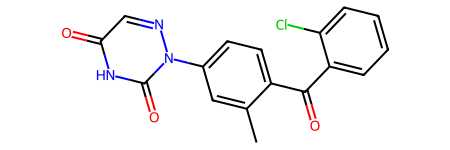

In [17]:
Chem.MolFromSmiles(records[0][1])

In [18]:
# --- Step 2: Compute molecular properties ---
def calc_esol(m):
    """Estimate solubility (logS) using ESOL-like model."""
    mw = Descriptors.MolWt(m)
    logp = Crippen.MolLogP(m)
    rb = rdMolDescriptors.CalcNumRotatableBonds(m)
    ap = rdMolDescriptors.CalcFractionCSP3(m)
    return 0.16 - 0.63*logp - 0.0062*mw + 0.066*rb - 0.74*ap

# Synthetic accessibility score (requires SA_Score module)
try:
    from rdkit.Chem import SA_Score
    def calc_sa(m): return SA_Score.sascorer.calculateScore(m)
except ImportError:
    def calc_sa(m): return np.nan

# Compute for all molecules
rows = []
for chembl_id, smi in tqdm(records, desc="Computing objectives"):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    qed_score = QED.qed(mol)
    logS = calc_esol(mol)
    sa = calc_sa(mol)
    rows.append({
        "chembl_id": chembl_id,
        "smiles": smi,
        "qed_affinity": qed_score,
        "esol_logS": logS,
        # "sa_score": sa
    })

df = pd.DataFrame(rows)
print(f"✅ Computed properties for {len(df)} valid molecules")

Computing objectives: 100%|██████████| 100/100 [00:00<00:00, 1034.05it/s]

✅ Computed properties for 100 valid molecules


In [19]:
df

,chembl_id,smiles,qed_affinity,esol_logS
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,0.739338,-3.135985
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,0.727894,-2.582586
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,0.752308,-3.415501
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,0.742386,-2.510784
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,0.739338,-3.135985
...,...,...,...,...
95,CHEMBL6346,O=C(C1CCCCN1)N1CCN(Cc2cccnc2)CC1,0.896389,-2.439326
96,CHEMBL414181,c1cncc(CN2CCN(C[C@@H]3CCCN3)CC2)c1,0.873301,-2.282976
97,CHEMBL6334,c1cc(CN2CCN(C[C@@H]3CCCN3)CC2)ccn1,0.873301,-2.282976
98,CHEMBL263076,O=c1oc2c(O)c(O)ccc2c2cc(F)ccc12,0.362959,-2.939192


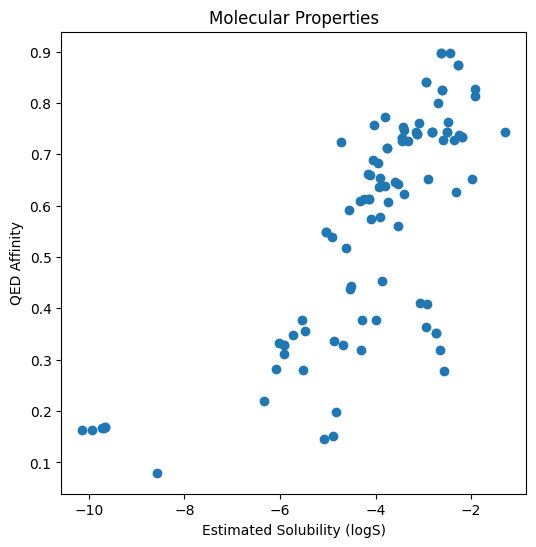

In [20]:
# Scatter plot of QED vs logS
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(df['esol_logS'], df['qed_affinity'])
plt.xlabel('Estimated Solubility (logS)')
plt.ylabel('QED Affinity')
plt.title('Molecular Properties')
plt.show()

In [21]:
# Define the "sweet spot" parameters
LOGS_TARGET = -3.0   # ideal solubility (log10 mol/L)
SIGMA = 1.0          # acceptable deviation range

# Gaussian-shaped sweet-spot objective
df["solubility_sweetspot"] = np.exp(-0.5 * ((df["esol_logS"] - LOGS_TARGET) / SIGMA) ** 2)

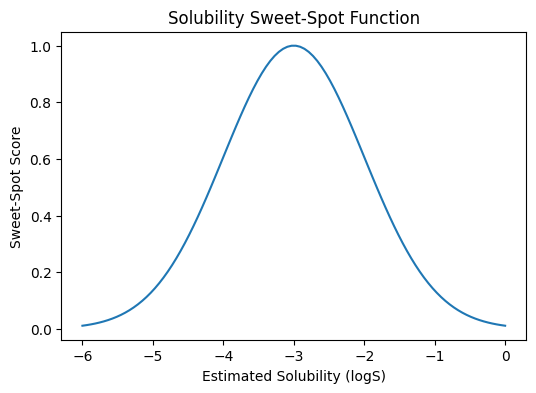

In [22]:
# Create a plot for the sweet-spot function
x = np.linspace(-6, 0, 100)
y = np.exp(-0.5 * ((x - LOGS_TARGET) / SIGMA) ** 2)
plt.figure(figsize=(6,4))
plt.plot(x, y)
plt.xlabel('Estimated Solubility (logS)')
plt.ylabel('Sweet-Spot Score')
plt.title('Solubility Sweet-Spot Function')
plt.show()

In [23]:
df

,chembl_id,smiles,qed_affinity,esol_logS,solubility_sweetspot
0,CHEMBL6329,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,0.739338,-3.135985,0.990797
1,CHEMBL6328,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,0.727894,-2.582586,0.916570
2,CHEMBL265667,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,0.752308,-3.415501,0.917300
3,CHEMBL6362,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,0.742386,-2.510784,0.887217
4,CHEMBL267864,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,0.739338,-3.135985,0.990797
...,...,...,...,...,...
95,CHEMBL6346,O=C(C1CCCCN1)N1CCN(Cc2cccnc2)CC1,0.896389,-2.439326,0.854552
96,CHEMBL414181,c1cncc(CN2CCN(C[C@@H]3CCCN3)CC2)c1,0.873301,-2.282976,0.773321
97,CHEMBL6334,c1cc(CN2CCN(C[C@@H]3CCCN3)CC2)ccn1,0.873301,-2.282976,0.773321
98,CHEMBL263076,O=c1oc2c(O)c(O)ccc2c2cc(F)ccc12,0.362959,-2.939192,0.998153


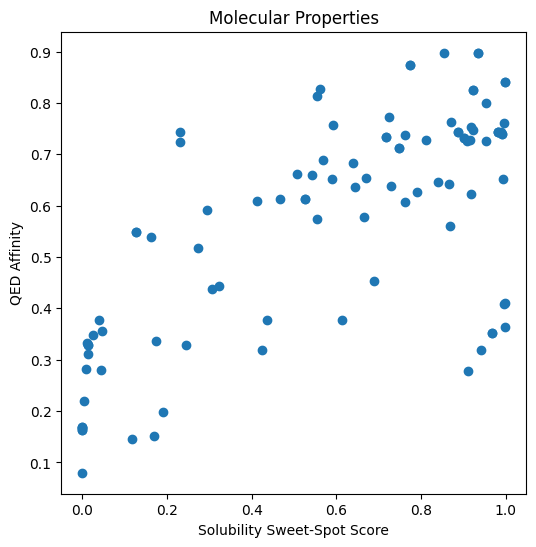

In [25]:
# Scatter plot of QED vs sweet-spot score
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(df['solubility_sweetspot'], df['qed_affinity'])
plt.xlabel('Solubility Sweet-Spot Score')
plt.ylabel('QED Affinity')
plt.title('Molecular Properties')
plt.show()